# Full Simulated 3D Scanner Pipeline

Acquisition, laser stripe extraction, point cloud reconstruction, Poisson meshing, Blender OBJ export, and Chamfer Distance.

In [1]:
%pip install opencv-python matplotlib open3d

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import importlib
import json
import subprocess
import sys

try:
    import cv2
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d.art3d import Poly3DCollection
    import numpy as np
    import open3d as o3d
except ImportError as exc:
    raise ImportError("Install notebook dependencies: pip install opencv-python matplotlib open3d") from exc

import reconstruct as reconstruct_module
importlib.reload(reconstruct_module)

ROOT = Path.cwd()

with open(ROOT / "config.json") as f:
    root_config = json.load(f)

dataset_name = root_config["active"]
config = root_config[dataset_name]
paths = config["paths"]

print(f"Dataset: {dataset_name}")


def point_cloud_from_array(points):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points.astype(np.float64))
    return pcd


def plot_points(points, title, limit=12000):
    if len(points) == 0:
        raise ValueError("No points to plot")

    count = min(limit, len(points))
    rng = np.random.default_rng(0)
    sample = points[rng.choice(len(points), count, replace=False)]

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(sample[:, 0], sample[:, 1], sample[:, 2], s=1)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    extent = np.ptp(sample, axis=0)
    if np.all(extent > 0):
        ax.set_box_aspect(extent)

    plt.tight_layout()


def plot_mesh(mesh, title, max_triangles=60000):
    mesh_to_plot = mesh
    if len(mesh_to_plot.triangles) > max_triangles:
        mesh_to_plot = mesh_to_plot.simplify_quadric_decimation(max_triangles)
        mesh_to_plot.remove_degenerate_triangles()
        mesh_to_plot.remove_duplicated_triangles()
        mesh_to_plot.remove_duplicated_vertices()

    verts = np.asarray(mesh_to_plot.vertices)
    tris = np.asarray(mesh_to_plot.triangles)
    tri_verts = verts[tris]  # (N, 3, 3)

    # per-face normal for simple diffuse shading
    e1 = tri_verts[:, 1] - tri_verts[:, 0]
    e2 = tri_verts[:, 2] - tri_verts[:, 0]
    normals = np.cross(e1, e2)
    norms = np.linalg.norm(normals, axis=1, keepdims=True)
    normals /= np.where(norms > 0, norms, 1)

    light = np.array([0.5, 0.5, 1.0])
    light /= np.linalg.norm(light)
    intensity = np.clip(normals @ light, 0, 1) * 0.6 + 0.35
    colors = plt.cm.Blues_r(intensity)

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")
    poly = Poly3DCollection(tri_verts, facecolors=colors, linewidth=0, alpha=1.0)
    ax.add_collection3d(poly)

    lo, hi = verts.min(axis=0), verts.max(axis=0)
    ax.set_xlim(lo[0], hi[0])
    ax.set_ylim(lo[1], hi[1])
    ax.set_zlim(lo[2], hi[2])
    ax.set_box_aspect(hi - lo)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    plt.tight_layout()

Dataset: asteroid


## 0. Camera Poses & Turntable Calibration

Use sampled ChArUco board frames from `scanner_asteroid_new_checkerboard` to estimate camera-to-board poses, camera extrinsics in the fitted turntable frame, and the turntable rotation axis and center.

In [3]:
cam_cal_path = ROOT / f"camera_calibration_{dataset_name}.json"

result = subprocess.run(
    [sys.executable, "calibrate_camera.py", "--max-frames", "360", "--min-corners", "35", "--output", str(cam_cal_path)],
    cwd=ROOT,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
result.check_returncode()

with open(cam_cal_path) as f:
    cam_cal = json.load(f)

with open(ROOT / "config.json") as f:
    root_config = json.load(f)
dataset_name = root_config["active"]
config = root_config[dataset_name]
paths = config["paths"]

K_pose = np.array(cam_cal["camera_matrix"])

print(f"Pose reprojection RMS : {cam_cal['rms_reprojection']:.4f} px")
print(f"Pose reprojection p95 : {cam_cal['p95_reprojection']:.4f} px")
print(f"Poses used            : {cam_cal['poses_used']} / {cam_cal['frames_sampled']} sampled / {cam_cal['frames_total']} total")
print(f"Poses used for axis   : {cam_cal['poses_used_for_axis']}")
print()
print("Camera K used:")
print(f"  fx={K_pose[0,0]:.2f}  fy={K_pose[1,1]:.2f}  cx={K_pose[0,2]:.2f}  cy={K_pose[1,2]:.2f}")
print()
print(f"Disk center (world) : {[round(v,4) for v in cam_cal['disk_center_world']]}")
print(f"Disk axis   (world) : {[round(v,4) for v in cam_cal['disk_axis_world']]}")
print(f"Circle residual mean: {cam_cal['disk_circle_residual_mean']:.5f}")
print(f"Circle residual p95 : {cam_cal['disk_circle_residual_p95']:.5f}")
print()
est = cam_cal['estimated_extrinsics']
cfg_ext = cam_cal['config_extrinsics']
print(f"Estimated camera location: {[round(v,4) for v in est['camera_location_world']]}")
print(f"Config camera location   : {[round(v,4) for v in cfg_ext['camera_location_world']]}")

Saved calibration to /Users/delia/uni/computer_vision/Project/ComputerVision/camera_calibration_asteroid.json
Pose reprojection RMS: 1.6284 px
fx=1120.00  fy=1120.00  cx=512.00  cy=512.00
disk_center_world: [-0.14681283364840747, 1.1200481114386838, -0.4503627770584205]
disk_axis_world:   [0.23753618760019124, 0.14796314755640452, 0.9600434711749091]
estimated_camera_location: [3.8478121944044634, -7.830063691826111, 3.1059472123924916]
poses used: 189 / 360 sampled / 360 total

Pose reprojection RMS : 1.6284 px
Pose reprojection p95 : 3.2568 px
Poses used            : 189 / 360 sampled / 360 total
Poses used for axis   : 171

Camera K used:
  fx=1120.00  fy=1120.00  cx=512.00  cy=512.00

Disk center (world) : [-0.1468, 1.12, -0.4504]
Disk axis   (world) : [0.2375, 0.148, 0.96]
Circle residual mean: 0.20375
Circle residual p95 : 0.46189

Estimated camera location: [3.8478, -7.8301, 3.1059]
Config camera location   : [0.0, -7.0, 4.0]


## 0b. Laser Plane Calibration

Use 4 tilted ChArUco board images (`scanner_asteroid_new_checkerboards`) to fit the laser plane in world coordinates via ray–board intersection + robust SVD plane fit.

In [4]:
laser_cal_path = ROOT / config["calibration"]["laser_calibration_output"]

result = subprocess.run(
    [sys.executable, "calibrate_laser.py", "--update-config"],
    cwd=ROOT,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
result.check_returncode()

with open(ROOT / "config.json") as f:
    root_config = json.load(f)
dataset_name = root_config["active"]
config = root_config[dataset_name]
paths = config["paths"]

with open(laser_cal_path) as f:
    laser_cal = json.load(f)

wp = laser_cal["world_plane"]
print(f"Laser plane normal (world): {[round(v,5) for v in wp['normal']]}")
print(f"Laser plane point  (world): {[round(v,5) for v in wp['point']]}")
print(f"Points kept: {laser_cal['kept_points']} / {laser_cal['total_points']}")
print()
for img_info in laser_cal["images"]:
    name = Path(img_info["image"]).name
    print(f"  {name}: {img_info['used_points']} stripe pts, {img_info['charuco_corners']} ChArUco corners")

Laser calibration points: 934 / 1089
Normal: [-0.967111690405594, -0.209582332211665, -0.14411878540132758]
Point:  [0.12684186516925772, -0.34854226920479414, 1.455804699179507]
Saved:  laser_calibration_asteroid.json

Laser plane normal (world): [-0.96711, -0.20958, -0.14412]
Laser plane point  (world): [0.12684, -0.34854, 1.4558]
Points kept: 934 / 1089

  checkerboard_1.png: 290 stripe pts, 63 ChArUco corners
  checkerboard_2.png: 188 stripe pts, 64 ChArUco corners
  checkerboard_3.png: 291 stripe pts, 70 ChArUco corners
  checkerboard_4.png: 320 stripe pts, 70 ChArUco corners


## 1. Acquisition Frames

render dir: /Users/delia/uni/computer_vision/Project/ComputerVision/scanner_asteroid_new
render glob: asteroid20grad*.png
frames:     360 / 360


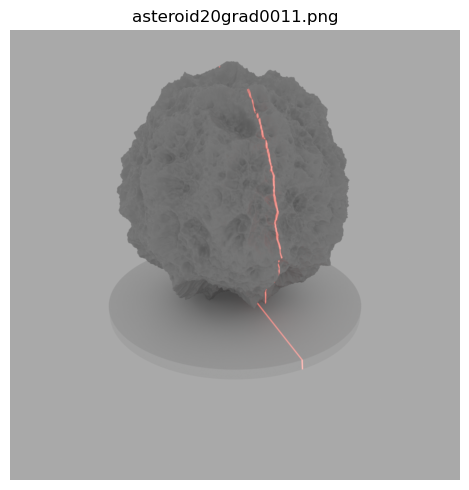

In [5]:
render_dir = ROOT / paths["input_dir"]
render_glob = paths.get("input_glob", "scan_*.png")
renders = sorted(render_dir.glob(render_glob))

print(f"render dir: {render_dir}")
print(f"render glob: {render_glob}")
print(f"frames:     {len(renders)} / {config['disk']['n_frames']}")

assert renders, f"No rendered frames found in {render_dir}"

frame = min(10, len(renders) - 1)
image = cv2.cvtColor(cv2.imread(str(renders[frame])), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(renders[frame].name)
plt.axis("off")
plt.tight_layout()

## 2. Laser Stripe Extraction

Dataset: asteroid
asteroid20grad0001: 456 stripe points (row-wise Gaussian peaks)
asteroid20grad0002: 207 stripe points (row-wise Gaussian peaks)
asteroid20grad0003: 194 stripe points (row-wise Gaussian peaks)
asteroid20grad0004: 453 stripe points (row-wise Gaussian peaks)
asteroid20grad0005: 210 stripe points (row-wise Gaussian peaks)
asteroid20grad0006: 197 stripe points (row-wise Gaussian peaks)
asteroid20grad0007: 202 stripe points (row-wise Gaussian peaks)
asteroid20grad0008: 452 stripe points (row-wise Gaussian peaks)
asteroid20grad0009: 446 stripe points (row-wise Gaussian peaks)
asteroid20grad0010: 443 stripe points (row-wise Gaussian peaks)
asteroid20grad0011: 444 stripe points (row-wise Gaussian peaks)
asteroid20grad0012: 268 stripe points (row-wise Gaussian peaks)
asteroid20grad0013: 226 stripe points (row-wise Gaussian peaks)
asteroid20grad0014: 448 stripe points (row-wise Gaussian peaks)
asteroid20grad0015: 454 stripe points (row-wise Gaussian peaks)
asteroid20grad0016: 45

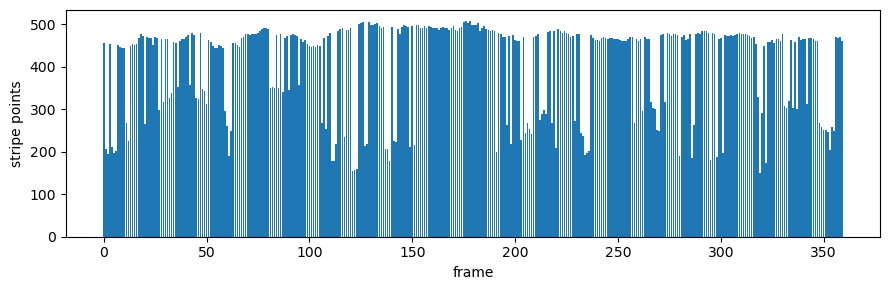

In [6]:
subprocess.run([sys.executable, "extract_stripes.py"], cwd=ROOT, check=True)

mask_glob = render_glob
coord_glob = Path(render_glob).stem + ".npy"
masks = sorted((ROOT / paths["stripe_masks_dir"]).glob(mask_glob))
coords = sorted((ROOT / paths["stripe_coords_dir"]).glob(coord_glob))
counts = np.array([len(np.load(path)) for path in coords])

print(f"masks:  {len(masks)}")
print(f"coords: {len(coords)}")
print(f"stripe points per frame: min {counts.min()}  mean {counts.mean():.1f}  max {counts.max()}")

plt.figure(figsize=(9, 3))
plt.bar(range(len(counts)), counts)
plt.xlabel("frame")
plt.ylabel("stripe points")
plt.tight_layout()

## 3. Centerline Check

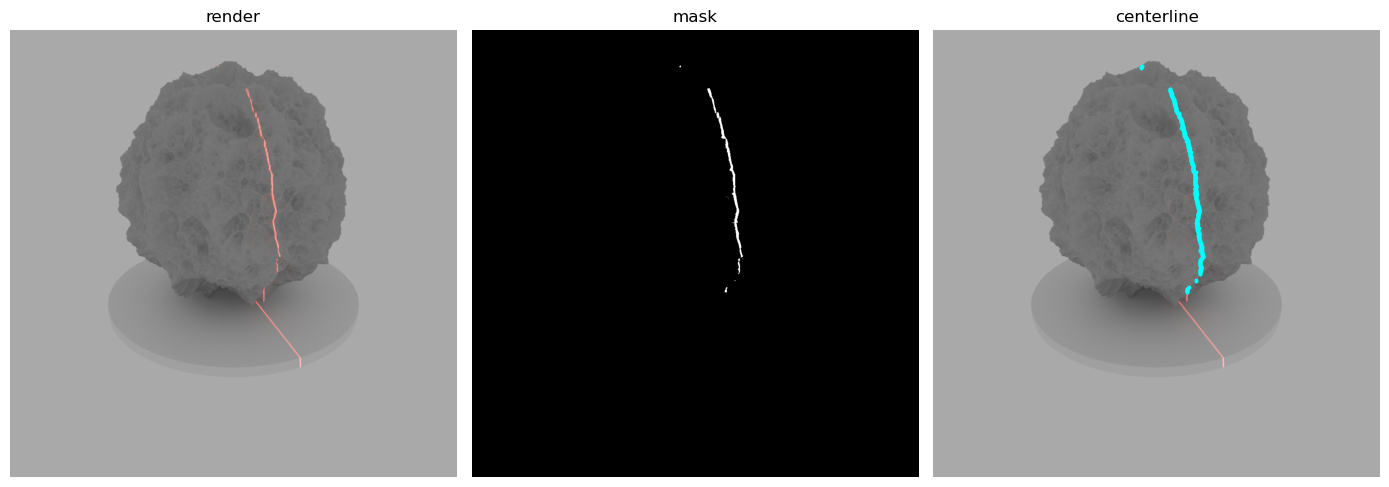

In [7]:
frame = min(10, len(renders) - 1)

image = cv2.cvtColor(cv2.imread(str(renders[frame])), cv2.COLOR_BGR2RGB)
mask = cv2.imread(str(masks[frame]), cv2.IMREAD_GRAYSCALE)
centerline = np.load(coords[frame])

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(image)
axes[0].set_title("render")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("mask")
axes[2].imshow(image)
axes[2].scatter(centerline[:, 1], centerline[:, 0], s=3, c="cyan")
axes[2].set_title("centerline")

for ax in axes:
    ax.axis("off")

plt.tight_layout()

## 4. Point Cloud Reconstruction

points: 148973
saved:  /Users/delia/uni/computer_vision/Project/ComputerVision/point_cloud_asteroid_new.ply
min:    [-2.6709094  -2.4270086  -0.17640027]
max:    [2.6893709 2.628298  3.608208 ]
mean:   [4.1607556e-05 3.0264050e-02 2.4797397e+00]


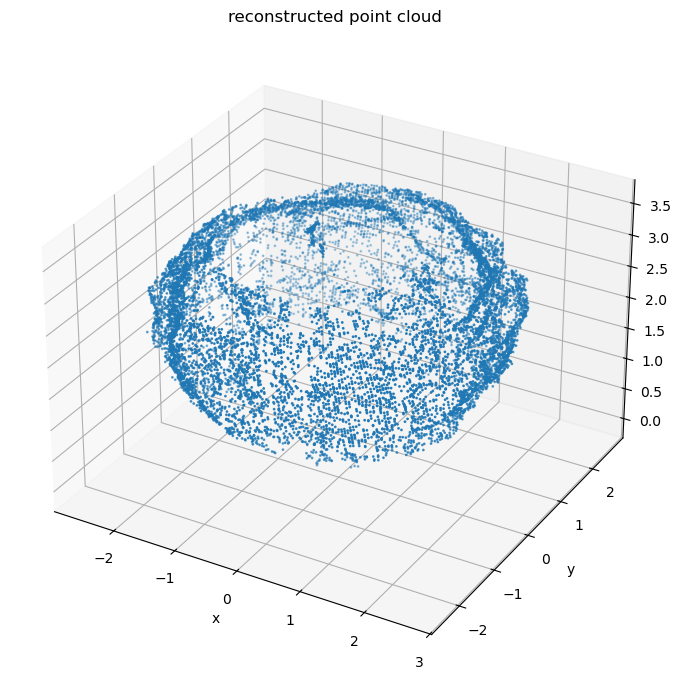

In [8]:
points = reconstruct_module.reconstruct(config)
point_cloud_path = ROOT / paths["point_cloud"]
reconstruct_module.save_ply(points, point_cloud_path)

print(f"points: {len(points)}")
print(f"saved:  {point_cloud_path}")
print(f"min:    {points.min(axis=0)}")
print(f"max:    {points.max(axis=0)}")
print(f"mean:   {points.mean(axis=0)}")

plot_points(points, "reconstructed point cloud")

radius p05/p50/p95: [1.48307784 2.25610471 2.53425984]
z      p05/p50/p95: [1.33764112 2.56131673 3.38254733]


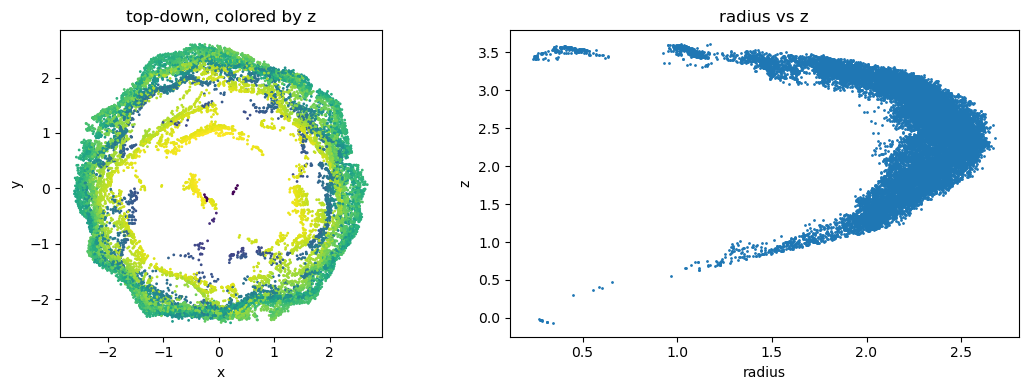

In [9]:
r_xy = np.linalg.norm(points[:, :2], axis=1)
print(f"radius p05/p50/p95: {np.percentile(r_xy, [5, 50, 95])}")
print(f"z      p05/p50/p95: {np.percentile(points[:, 2], [5, 50, 95])}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
idx = np.random.default_rng(1).choice(len(points), min(20000, len(points)), replace=False)
sample = points[idx]
axes[0].scatter(sample[:, 0], sample[:, 1], c=sample[:, 2], s=1, cmap="viridis")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("top-down, colored by z")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[1].scatter(r_xy[idx], sample[:, 2], s=1)
axes[1].set_title("radius vs z")
axes[1].set_xlabel("radius")
axes[1].set_ylabel("z")
plt.tight_layout()

In [10]:
import copy


def geometry_summary(label, cfg):
    pts = reconstruct_module.reconstruct(cfg)
    if len(pts) == 0:
        print(f"{label:28s} -> 0 points")
        return None
    r_xy = np.linalg.norm(pts[:, :2], axis=1)
    print(
        f"{label:28s} n={len(pts):6d}  "
        f"r50/r95={np.percentile(r_xy, [50, 95]).round(3)}  "
        f"z05/z95={np.percentile(pts[:, 2], [5, 95]).round(3)}"
    )
    return pts

print("Current reconstruction variants:")
geometry_summary("config", config)

for focal_scale in [0.75, 1.25, 1.5, 1.75]:
    cfg = copy.deepcopy(config)
    cfg["camera"]["fx_px"] = K_pose[0, 0] * focal_scale if "K_pose" in globals() else reconstruct_module.build_camera_matrix(config["camera"])[0, 0] * focal_scale
    cfg["camera"]["fy_px"] = cfg["camera"]["fx_px"]
    geometry_summary(f"focal x{focal_scale:g}", cfg)

for center in ([0, 0, 0], [-0.152243, 1.121539, 0], [-0.152243, 1.121539, -0.451906], [0, 1.121539, 0]):
    cfg = copy.deepcopy(config)
    cfg["disk"]["center"] = list(center)
    geometry_summary(f"disk center {center}", cfg)

for direction in [1.0, -1.0]:
    cfg = copy.deepcopy(config)
    cfg["disk"]["rotation_direction"] = direction
    geometry_summary(f"rotation dir {direction:+g}", cfg)


Current reconstruction variants:
config                       n=148973  r50/r95=[2.256 2.534]  z05/z95=[1.338 3.383]
focal x0.75                  n=144417  r50/r95=[2.804 3.094]  z05/z95=[1.538 3.828]
focal x1.25                  n=148973  r50/r95=[1.85  2.109]  z05/z95=[1.186 2.985]
focal x1.5                   n=148973  r50/r95=[1.533 1.775]  z05/z95=[1.071 2.674]
focal x1.75                  n=148973  r50/r95=[1.279 1.506]  z05/z95=[0.981 2.424]
disk center [0, 0, 0]        n=148973  r50/r95=[2.256 2.534]  z05/z95=[1.338 3.383]
disk center [-0.152243, 1.121539, 0] n=148973  r50/r95=[3.387 3.665]  z05/z95=[1.338 3.383]
disk center [-0.152243, 1.121539, -0.451906] n=148065  r50/r95=[3.389 3.665]  z05/z95=[1.788 3.821]
disk center [0, 1.121539, 0] n=148973  r50/r95=[3.366 3.643]  z05/z95=[1.338 3.383]
rotation dir +1              n=148973  r50/r95=[2.256 2.534]  z05/z95=[1.338 3.383]
rotation dir -1              n=148973  r50/r95=[2.256 2.534]  z05/z95=[1.338 3.383]


In [11]:
base_laser_normal = np.array(config["laser"]["normal"], dtype=np.float64)
base_laser_normal /= np.linalg.norm(base_laser_normal)
base_laser_point = np.array(config["laser"]["point"], dtype=np.float64)
base_plane_offset = float(base_laser_normal @ base_laser_point)

print(f"Base laser plane offset n.p: {base_plane_offset:.6f}")
print("Laser plane offset sweep:")
for offset_scale in [0.4, 0.55, 0.7, 0.85, 1.0, 1.15, 1.3]:
    cfg = copy.deepcopy(config)
    cfg["laser"]["normal"] = base_laser_normal.tolist()
    cfg["laser"]["point"] = (base_laser_normal * base_plane_offset * offset_scale).tolist()
    geometry_summary(f"laser offset x{offset_scale:g}", cfg)

print("Laser z-tilt sweep:")
for normal_z_delta in [-0.08, -0.04, 0.0, 0.04, 0.08]:
    cfg = copy.deepcopy(config)
    normal = base_laser_normal.copy()
    normal[2] += normal_z_delta
    normal /= np.linalg.norm(normal)
    cfg["laser"]["normal"] = normal.tolist()
    cfg["laser"]["point"] = (normal * base_plane_offset).tolist()
    geometry_summary(f"normal dz {normal_z_delta:+.2f}", cfg)


Base laser plane offset n.p: -0.259431
Laser plane offset sweep:
laser offset x0.4            n=148973  r50/r95=[2.889 3.128]  z05/z95=[1.698 3.466]
laser offset x0.55           n=148973  r50/r95=[2.73  2.978]  z05/z95=[1.608 3.445]
laser offset x0.7            n=148973  r50/r95=[2.571 2.83 ]  z05/z95=[1.518 3.424]
laser offset x0.85           n=148973  r50/r95=[2.413 2.682]  z05/z95=[1.428 3.403]
laser offset x1              n=148973  r50/r95=[2.256 2.534]  z05/z95=[1.338 3.383]
laser offset x1.15           n=148972  r50/r95=[2.1   2.387]  z05/z95=[1.248 3.362]
laser offset x1.3            n=148852  r50/r95=[1.944 2.242]  z05/z95=[1.161 3.341]
Laser z-tilt sweep:
normal dz -0.08              n=148972  r50/r95=[3.168 3.375]  z05/z95=[1.631 3.532]
normal dz -0.04              n=148973  r50/r95=[2.684 2.916]  z05/z95=[1.47  3.456]
normal dz +0.00              n=148973  r50/r95=[2.256 2.534]  z05/z95=[1.338 3.383]
normal dz +0.04              n=148973  r50/r95=[1.895 2.214]  z05/z95=[1.22

In [12]:
import copy
import calibrate_laser as calibrate_laser_module
importlib.reload(calibrate_laser_module)

base_square_length = float(config["calibration"]["charuco"]["square_length"])
gt_mesh_for_scale = o3d.io.read_triangle_mesh(str(ROOT / paths["ground_truth_mesh"]))
gt_sample_for_scale = np.asarray(gt_mesh_for_scale.sample_points_uniformly(number_of_points=50000).points)
gt_radius_p95_for_scale = float(np.percentile(np.linalg.norm(gt_sample_for_scale[:, :2], axis=1), 95))
print(f"GT radius p95 target: {gt_radius_p95_for_scale:.4f}")
print(f"Base ChArUco square length: {base_square_length:.6f}")

best_scale = None
best_error = np.inf
best_plane = None
for square_scale in np.linspace(0.78, 0.96, 10):
    cfg_root = copy.deepcopy(root_config)
    cfg = cfg_root[dataset_name]
    cfg["calibration"]["charuco"]["square_length"] = base_square_length * float(square_scale)
    laser_result = calibrate_laser_module.calibrate_laser(cfg_root)
    cfg["laser"] = {
        "normal": laser_result["world_plane"]["normal"],
        "point": laser_result["world_plane"]["point"],
    }
    pts = reconstruct_module.reconstruct(cfg)
    r95 = float(np.percentile(np.linalg.norm(pts[:, :2], axis=1), 95))
    error = abs(r95 - gt_radius_p95_for_scale)
    print(
        f"square x{square_scale:.3f} -> square={cfg['calibration']['charuco']['square_length']:.6f}  "
        f"r95={r95:.4f}  error={error:.4f}  points={len(pts)}"
    )
    if error < best_error:
        best_error = error
        best_scale = float(square_scale)
        best_plane = laser_result["world_plane"]

print()
print(f"Best square scale: {best_scale:.3f}")
print(f"Best square length: {base_square_length * best_scale:.6f}")
print(f"Best plane normal: {[round(v, 8) for v in best_plane['normal']]}")
print(f"Best plane point:  {[round(v, 8) for v in best_plane['point']]}")


GT radius p95 target: 1.6440
Base ChArUco square length: 0.217775
square x0.780 -> square=0.169865  r95=3.5023  error=1.8584  points=148973
square x0.800 -> square=0.174220  r95=3.4136  error=1.7696  points=148973
square x0.820 -> square=0.178576  r95=3.3250  error=1.6811  points=148973
square x0.840 -> square=0.182931  r95=3.2366  error=1.5926  points=148973
square x0.860 -> square=0.187287  r95=3.1481  error=1.5042  points=148973
square x0.880 -> square=0.191642  r95=3.0599  error=1.4160  points=148973
square x0.900 -> square=0.195998  r95=2.9718  error=1.3279  points=148973
square x0.920 -> square=0.200353  r95=2.8839  error=1.2399  points=148973
square x0.940 -> square=0.204709  r95=2.7962  error=1.1522  points=148973
square x0.960 -> square=0.209064  r95=2.7087  error=1.0647  points=148973

Best square scale: 0.960
Best square length: 0.209064
Best plane normal: [-0.96711169, -0.20958233, -0.14411878]
Best plane point:  [0.12176819, -0.61460073, 1.55757257]


gt radius p05/p50/p95: [0.4865772  1.36307797 1.64477076]
gt z      p05/p50/p95: [0.31104992 1.81200092 3.22984279]


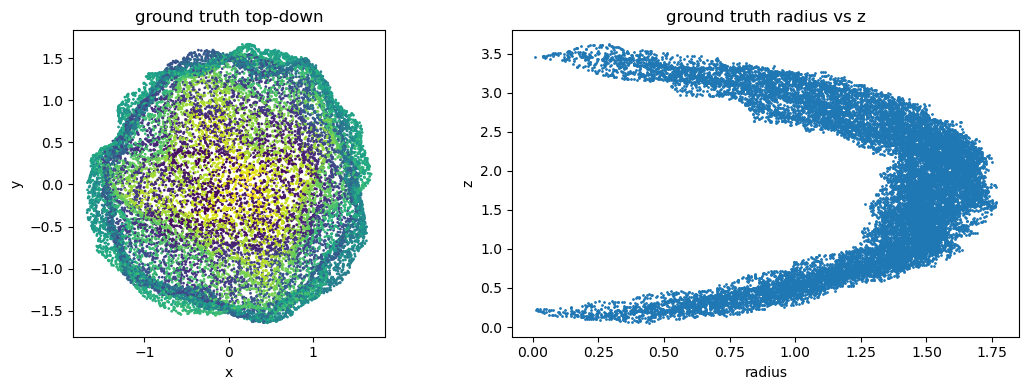

In [13]:
gt_mesh_for_shape = o3d.io.read_triangle_mesh(str(ROOT / paths["ground_truth_mesh"]))
gt_sample_shape = np.asarray(gt_mesh_for_shape.sample_points_uniformly(number_of_points=60000).points)

gt_radius = np.linalg.norm(gt_sample_shape[:, :2], axis=1)
print(f"gt radius p05/p50/p95: {np.percentile(gt_radius, [5, 50, 95])}")
print(f"gt z      p05/p50/p95: {np.percentile(gt_sample_shape[:, 2], [5, 50, 95])}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
idx_gt = np.random.default_rng(2).choice(len(gt_sample_shape), min(20000, len(gt_sample_shape)), replace=False)
gt_plot = gt_sample_shape[idx_gt]
axes[0].scatter(gt_plot[:, 0], gt_plot[:, 1], c=gt_plot[:, 2], s=1, cmap="viridis")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("ground truth top-down")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[1].scatter(gt_radius[idx_gt], gt_plot[:, 2], s=1)
axes[1].set_title("ground truth radius vs z")
axes[1].set_xlabel("radius")
axes[1].set_ylabel("z")
plt.tight_layout()

## 5. Poisson Surface Reconstruction and Blender Export

[Open3D WARNING] Write OBJ can not include triangle normals.
mesh vertices:  147753
mesh triangles: 294336
saved PLY:      /Users/delia/uni/computer_vision/Project/ComputerVision/mesh_asteroid_new.ply



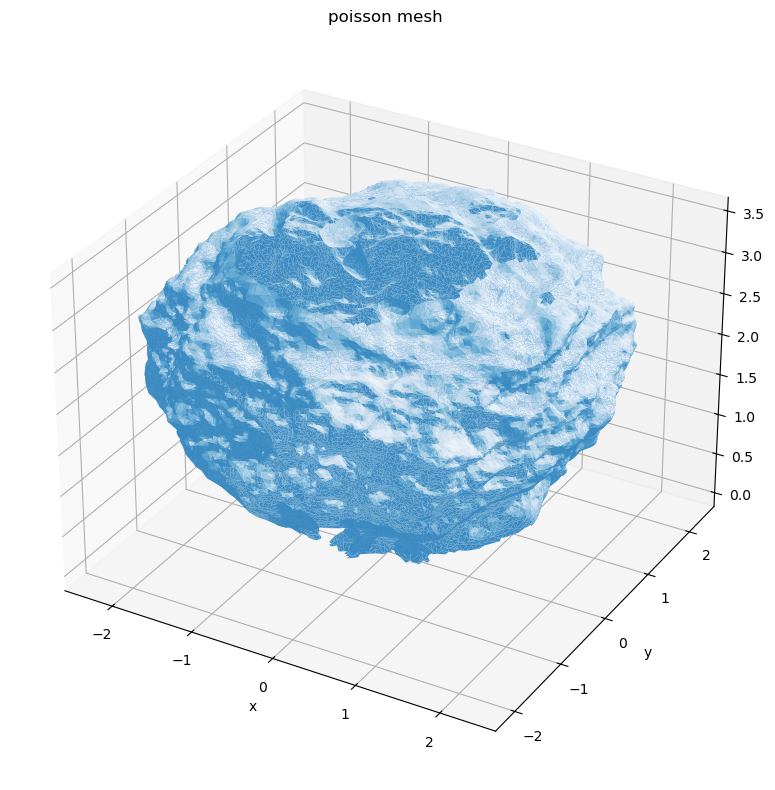

In [14]:
mesh_path = ROOT / paths["reconstructed_mesh"]
mesh_obj_path = ROOT / paths.get(
    "reconstructed_mesh_obj",
    Path(paths["reconstructed_mesh"]).with_suffix(".obj").name,
)

mesh = reconstruct_module.reconstruct_surface(points, str(mesh_path))
reconstruct_module.export_mesh(mesh, str(mesh_obj_path))

print(f"mesh vertices:  {len(mesh.vertices)}")
print(f"mesh triangles: {len(mesh.triangles)}")
print(f"saved PLY:      {mesh_path.resolve()}")
print()

plot_mesh(mesh, "poisson mesh")

## 6. Chamfer Distance

{
  "reconstruction_to_ground_truth_mean": 0.23387204311821624,
  "ground_truth_to_reconstruction_mean": 0.34481280861179403,
  "chamfer_l1_mean": 0.28934242586500514,
  "chamfer_l2_mean": 0.12828970975921825,
  "reconstruction_to_ground_truth_p95": 0.5143680230398997,
  "ground_truth_to_reconstruction_p95": 0.8124956862948663,
  "dataset": "asteroid",
  "sample_count": 30000,
  "ground_truth_aligned_by_bbox": true
}
saved: /Users/delia/uni/computer_vision/Project/ComputerVision/metrics_asteroid_new.json


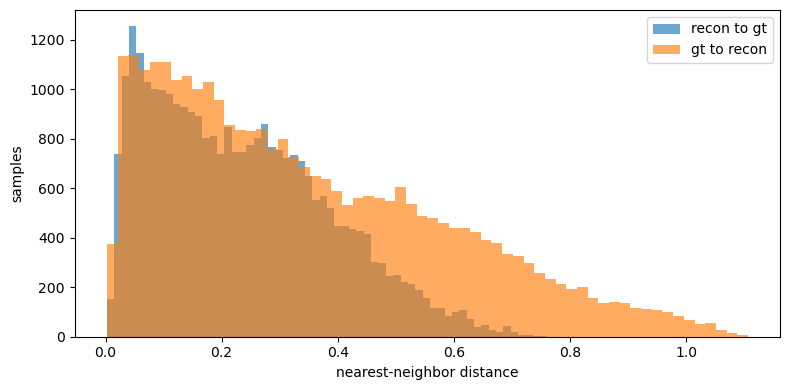

In [15]:
mesh_path = ROOT / paths["reconstructed_mesh"]
ground_truth_path = ROOT / paths["ground_truth_mesh"]
metrics_path = ROOT / paths["metrics"]

sample_count = 30000

if not ground_truth_path.exists():
    print(f"Missing ground truth mesh: {ground_truth_path}")
    print("Export the original Blender object to that path, then rerun this cell.")
else:
    metrics = reconstruct_module.validate_reconstruction(config, dataset_name, sample_count=sample_count)

    o3d.utility.random.seed(42)
    reconstruction_sample = reconstruct_module.sample_mesh(str(mesh_path), sample_count)
    ground_truth_sample = reconstruct_module.sample_mesh(str(ground_truth_path), sample_count)
    ground_truth_sample = reconstruct_module.align_by_bbox(ground_truth_sample, reconstruction_sample)

    d_recon_gt = np.asarray(reconstruction_sample.compute_point_cloud_distance(ground_truth_sample))
    d_gt_recon = np.asarray(ground_truth_sample.compute_point_cloud_distance(reconstruction_sample))

    print(json.dumps(metrics, indent=2))
    print(f"saved: {metrics_path}")

    plt.figure(figsize=(8, 4))
    plt.hist(d_recon_gt, bins=60, alpha=0.65, label="recon to gt")
    plt.hist(d_gt_recon, bins=60, alpha=0.65, label="gt to recon")
    plt.xlabel("nearest-neighbor distance")
    plt.ylabel("samples")
    plt.legend()
    plt.tight_layout()